# Gaussian Curve-Fit Test
Inject Gaussian spikes into HARPS spectra and search for them using Gaussian curve-fitting tool.

In [1]:
%matplotlib widget

In [2]:
eso_login = "goodmanj"
from astroquery.eso import Eso
eso = Eso()
eso.login(eso_login)

INFO: Authenticating goodmanj on www.eso.org... [astroquery.eso.core]
INFO: Authentication successful! [astroquery.eso.core]


In [3]:
import sys
sys.path.append("..")
import optical_seti_functions
import seti_catalog_functions
import Gaussian_Injector
import csv
import random
import matplotlib.pyplot as plt
import numpy as np
from specutils import Spectrum
from specutils.fitting import fit_lines
from astropy.modeling import models
from astropy import units as u
from matplotlib.ticker import FormatStrFormatter
from astropy.modeling.fitting import (LMLSQFitter,TRFLSQFitter,DogBoxLSQFitter)

In [4]:
import importlib
importlib.reload(Gaussian_Injector)
importlib.reload(optical_seti_functions)

<module 'optical_seti_functions' from 'c:\\Users\\goodm\\OneDrive\\Documents\\optical_seti\\injection\\..\\optical_seti_functions.py'>

In [5]:
file = 'ADP.2018-04-11T01:01:47.531.fits'
file = file.replace(":","_")
[wave,arr1] = optical_seti_functions.read_harps_file(file)
hits_start = 88115
hits_end = 88119

44.679726 151.54382 4662.785 0.03999999999996362
0.04669183319225852
0.04669183319225852
0.04669134204542738


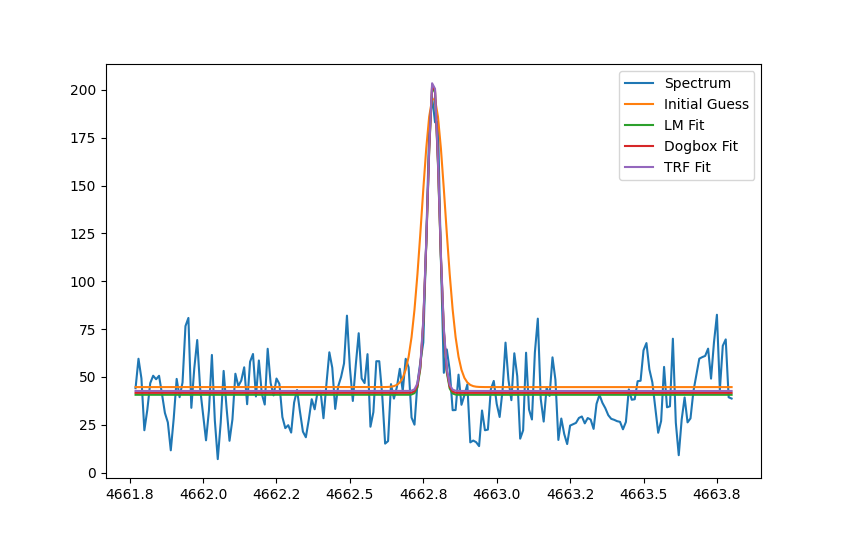

In [14]:

windowpoint1 = hits_start - 100
windowpoint2 = hits_end + 100

continuum = np.mean(arr1[windowpoint1:windowpoint2])
peak_guess = np.max(arr1[hits_start:hits_end])-continuum #makes a highly "educated guess" for the fitted curve's peak by taking the actual maximum from the subtracted continuum
mean_guess = np.mean(wave[hits_start:hits_end])
st_deviation_guess_wide = (wave[hits_end]-wave[hits_start]) * 1
print(continuum,peak_guess,mean_guess,st_deviation_guess_wide)
spectrum = Spectrum(flux=arr1[windowpoint1:windowpoint2]*u.dimensionless_unscaled, spectral_axis=wave[windowpoint1:windowpoint2]*u.AA)
g_init = models.Gaussian1D(amplitude=peak_guess*u.dimensionless_unscaled, mean=mean_guess*u.AA, stddev=st_deviation_guess_wide*u.AA) + models.Const1D(amplitude=continuum)
y_guess = g_init(wave[windowpoint1:windowpoint2]*u.AA)

plt.figure(1)
plt.clf()
plt.plot(spectrum.spectral_axis, spectrum.flux) 
plt.plot(wave[windowpoint1:windowpoint2], y_guess)

g_fit = fit_lines(spectrum, g_init, window=(wave[windowpoint1]*u.AA, wave[windowpoint2]*u.AA))
standard_deviation = g_fit[0].stddev.value
y_fit = g_fit(wave[windowpoint1:windowpoint2]*u.AA)
plt.plot(wave[windowpoint1:windowpoint2], y_fit)
fwhm = standard_deviation * 2.35
print(fwhm) 

fitter = TRFLSQFitter()
g_fit = fit_lines(spectrum, g_init, window=(wave[windowpoint1]*u.AA, wave[windowpoint2]*u.AA),get_fit_info=True,fitter=fitter)
standard_deviation = g_fit[0].stddev.value
y_fit = g_fit(wave[windowpoint1:windowpoint2]*u.AA)
plt.plot(wave[windowpoint1:windowpoint2], y_fit+1)
fwhm = standard_deviation * 2.35
print(fwhm) 

fitter = DogBoxLSQFitter()
g_fit = fit_lines(spectrum, g_init, window=(wave[windowpoint1]*u.AA, wave[windowpoint2]*u.AA),get_fit_info=True,fitter=fitter)
standard_deviation = g_fit[0].stddev.value
y_fit = g_fit(wave[windowpoint1:windowpoint2]*u.AA)
plt.plot(wave[windowpoint1:windowpoint2], y_fit+2)
fwhm = standard_deviation * 2.35
print(fwhm) 

plt.legend(['Spectrum','Initial Guess','LM Fit','Dogbox Fit','TRF Fit'])
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
plt.show()

0.04669155857500506


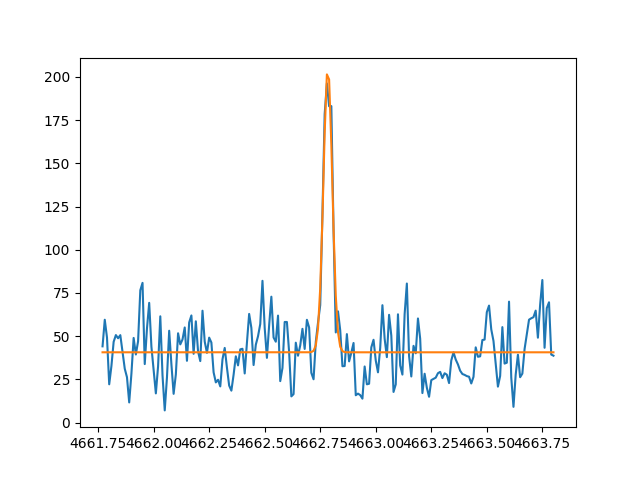

In [9]:
windowpoint1 = hits_start - 100
windowpoint2 = hits_end + 100
peak_guess = np.max(arr1[hits_start:hits_end]) #makes a highly "educated guess" for the fitted curve's peak by taking the actual maximum from the subtracted continuum
mean_guess = np.mean(wave[hits_start:hits_end])
st_deviation_guess_wide = (wave[hits_end] - wave[hits_start]) * 2
st_deviation_guess_narrow = (wave[hits_end] - wave[hits_start]) * 2
spectrum = Spectrum(flux=arr1[windowpoint1:windowpoint2]*u.dimensionless_unscaled, spectral_axis=wave[windowpoint1:windowpoint2]*u.AA)
g_init = models.Gaussian1D(amplitude=peak_guess*u.dimensionless_unscaled, mean=mean_guess*u.AA, stddev=st_deviation_guess_wide*u.AA) + models.Const1D(amplitude=0)
g_fit = fit_lines(spectrum, g_init, window=(wave[windowpoint1]*u.AA, wave[windowpoint2]*u.AA))
standard_deviation = g_fit[0].stddev.value
if standard_deviation < 1e-12: # Didn't find peak, try a narrower guess
    alternate_guess = models.Gaussian1D(amplitude=peak_guess*u.dimensionless_unscaled, mean=mean_guess*u.AA, stddev=st_deviation_guess_narrow*u.AA)  + models.Const1D(amplitude=0)
    g_fit = fit_lines(spectrum, alternate_guess, window=(wave[windowpoint1]*u.AA, wave[windowpoint2]*u.AA))
    standard_deviation= g_fit.stddev.value
fwhm = standard_deviation * 2.35
y_fit = g_fit(wave[windowpoint1:windowpoint2]*u.AA)
plt.figure(2)
plt.clf()
plt.plot(spectrum.spectral_axis, spectrum.flux) 
plt.plot(wave[windowpoint1:windowpoint2], y_fit)
print(fwhm) 
#Cosmic ray hits_start: 4082, green auroral emission line: 179487, 179487
#GJ551 HITS_STARTS: 13812, 39670 (something's odd), 43403, 45101, 59377, 64514, 67948, 76729, 80165
plt.show()
